# Section 1: LGD Exploration


## 1.1 Imports & Paths

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

RAW_DIR = Path("/Users/dongshuxin/Desktop/Projects/data")
ACCEPTED_FILE = RAW_DIR / "accepted_2007_to_2018Q4.csv.gz"

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1.2 Find rows about LGD 


In [5]:
lgd_cols = [
    "id",
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "issue_d",
    "loan_status",
    "purpose",
    "addr_state",
    "fico_range_low",
    "fico_range_high",
    "dti",
    "sub_grade",
    # 核心 recovery 字段
    "total_rec_prncp",
    "total_rec_int",
    "recoveries",
    "collection_recovery_fee",
    "out_prncp",
    "last_pymnt_amnt",
]

df_raw = pd.read_csv(
    ACCEPTED_FILE,
    compression="gzip",
    usecols=lgd_cols,
    low_memory=False,
)

print("Raw shape:", df_raw.shape)
df_raw["loan_status"].value_counts()

Raw shape: (2260701, 19)


loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

## 1.3 Find Charged Off loans

In [6]:
co_df = df_raw[df_raw["loan_status"] == "Charged Off"].copy()
print(f"Charged Off loans: {len(co_df):,}")

# 字段清洗
co_df["issue_d"] = pd.to_datetime(co_df["issue_d"], format="%b-%Y", errors="coerce")
co_df["term"] = co_df["term"].astype(str).str.extract(r"(\d+)").astype(float)
co_df["fico_avg"] = (co_df["fico_range_low"] + co_df["fico_range_high"]) / 2

# 看看 recovery 列的分布
co_df[["funded_amnt", "total_rec_prncp", "recoveries", "collection_recovery_fee"]].describe()

Charged Off loans: 268,559


,funded_amnt,total_rec_prncp,recoveries,collection_recovery_fee
count,268559.000000,268559.000000,268559.000000,268559.000000
mean,15557.059808,4387.877516,1209.456926,201.526243
std,8810.986735,4122.557902,1847.303239,329.318151
min,900.000000,0.000000,0.000000,0.000000
25%,9000.000000,1520.750000,0.000000,0.000000
50%,14325.000000,3157.310000,592.200000,80.100000
75%,20400.000000,5900.860000,1723.810000,283.560750
max,40000.000000,39989.790000,39859.550000,7174.719000


## 1.4 Calculate LGD

```
principal_recovered = total_rec_prncp + recoveries - collection_recovery_fee
LGD = 1 - principal_recovered / funded_amnt
```



Valid loans with EAD > $100: 268,404 / 268,559
Dropped: 155 loans with EAD <= $100 (likely data noise)

=== LGD comparison ===
          LGD_funded  LGD_outstanding
count  268559.000000    268404.000000
mean        0.634444         0.908670
std         0.214873         0.110653
min         0.000000         0.000000
25%         0.497487         0.880565
50%         0.676455         0.915423
75%         0.801353         1.000000
max         1.000000         1.000000


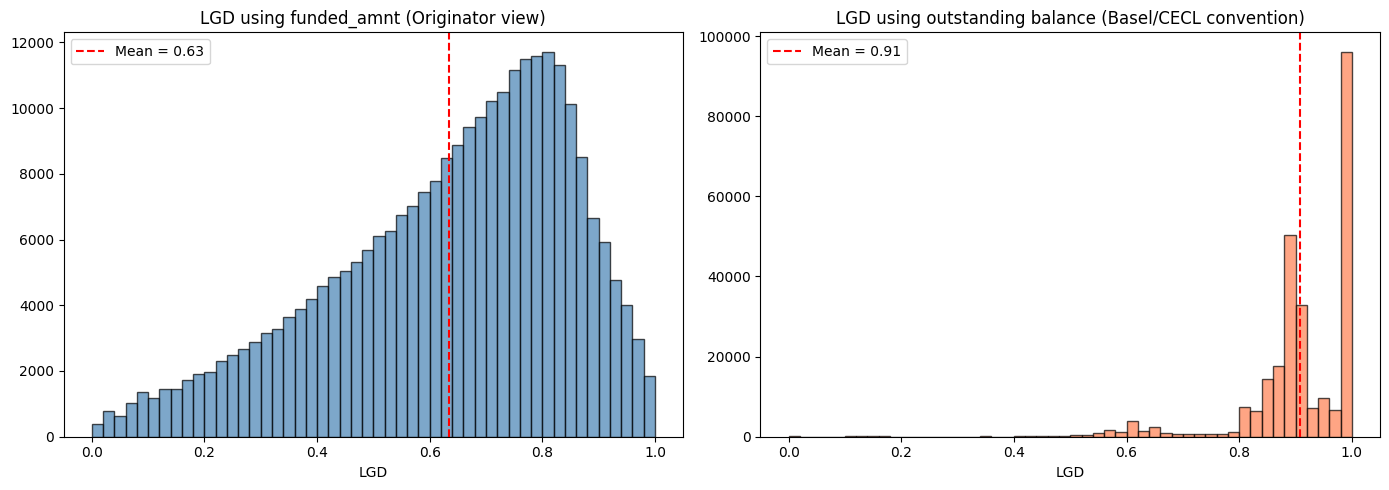

In [ ]:
# ========================================
# LGD 
# ========================================

# 口径 1: funded_amnt 
co_df["LGD_funded"] = co_df["LGD"]   

# 口径 2: outstanding balance at default 
co_df["ead_at_default"] = co_df["funded_amnt"] - co_df["total_rec_prncp"].fillna(0)
co_df["net_recovery"] = co_df["recoveries"].fillna(0) - co_df["collection_recovery_fee"].fillna(0)
co_df["actual_loss"] = co_df["ead_at_default"] - co_df["net_recovery"]


valid_mask = co_df["ead_at_default"] > 100  
print(f"Valid loans with EAD > $100: {valid_mask.sum():,} / {len(co_df):,}")
print(f"Dropped: {(~valid_mask).sum():,} loans with EAD <= $100 (likely data noise)")

co_df.loc[valid_mask, "LGD_outstanding"] = (
    co_df.loc[valid_mask, "actual_loss"] / co_df.loc[valid_mask, "ead_at_default"]
)
co_df["LGD_outstanding"] = co_df["LGD_outstanding"].clip(0, 1)

# Compare two types of LGD
print("\n=== LGD comparison ===")
print(co_df[["LGD_funded", "LGD_outstanding"]].describe())

# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(co_df["LGD_funded"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(co_df["LGD_funded"].mean(), color="red", linestyle="--",
                label=f"Mean = {co_df['LGD_funded'].mean():.2f}")
axes[0].set_title("LGD using funded_amnt (Originator view)")
axes[0].set_xlabel("LGD")
axes[0].legend()

axes[1].hist(co_df["LGD_outstanding"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(co_df["LGD_outstanding"].mean(), color="red", linestyle="--",
                label=f"Mean = {co_df['LGD_outstanding'].mean():.2f}")
axes[1].set_title("LGD using outstanding balance (Basel/CECL convention)")
axes[1].set_xlabel("LGD")
axes[1].legend()

plt.tight_layout()
plt.show()

In unsecured consumer lending, LGD is nearly a constant — 91% with a tight standard deviation of 11%. This means PD is the dominant driver of expected loss. Underwriting discipline (PD management) outweighs recovery efforts (LGD management) in this asset class — the right strategic priority is default prevention, not post-default collection.

## 1.6 LGD by Purpose

                   LGD_funded         LGD_outstanding        
                         mean   count            mean   count
purpose                                                      
major_purchase       0.665442    5473        0.914948    5467
house                0.686008    1587        0.914801    1586
small_business       0.665438    4580        0.914800    4578
car                  0.615094    2141        0.913769    2141
medical              0.658403    3387        0.911440    3383
home_improvement     0.647516   15502        0.910734   15486
credit_card          0.608501   49982        0.909474   49964
other                0.649842   16385        0.909065   16366
moving               0.655952    2214        0.908034    2211
debt_consolidation   0.636793  165014        0.907704  164935
vacation             0.624413    1738        0.906775    1733
renewable_energy     0.664186     221        0.906687     221
wedding              0.597007     279        0.890692     278
educatio

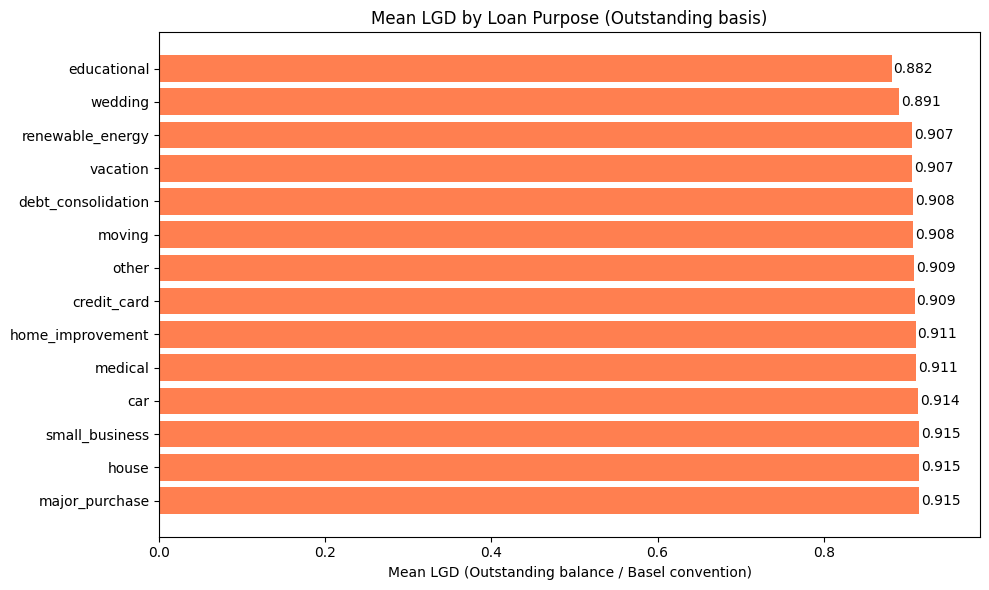

In [ ]:
lgd_by_purpose = (
    co_df.groupby("purpose")[["LGD_funded", "LGD_outstanding"]]
    .agg(["mean", "count"])
    .sort_values(("LGD_outstanding", "mean"), ascending=False)
)
print(lgd_by_purpose)

# Show LGD_outstanding
fig, ax = plt.subplots(figsize=(10, 6))
values = lgd_by_purpose[("LGD_outstanding", "mean")]
bars = ax.barh(values.index, values.values, color="coral")


for bar, val in zip(bars, values.values):
    ax.text(
        val + 0.002,                      
        bar.get_y() + bar.get_height()/2, 
        f"{val:.3f}",                 
        va="center",
        fontsize=10,
    )

ax.set_xlabel("Mean LGD (Outstanding balance / Basel convention)")
ax.set_title("Mean LGD by Loan Purpose (Outstanding basis)")
ax.set_xlim(0, max(values.values) * 1.08)  
plt.tight_layout()
plt.show()

## 1.7 LGD by FICO Band

          LGD_funded         LGD_outstanding        
                mean   count            mean   count
fico_band                                           
<640             NaN       0             NaN       0
640-680     0.631449  116176        0.906166  116104
680-720     0.633313  120008        0.909234  119950
720-760     0.643070   25969        0.914513   25950
760+        0.674962    6406        0.919838    6400


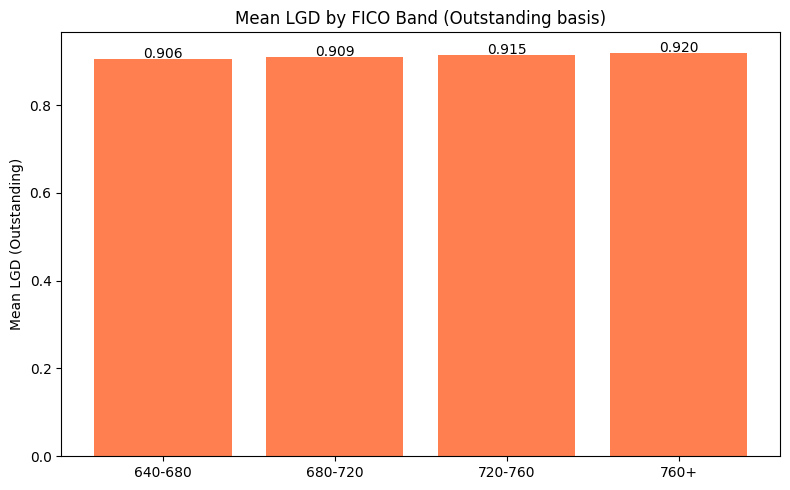

In [ ]:
co_df["fico_band"] = pd.cut(
    co_df["fico_avg"],
    bins=[0, 640, 680, 720, 760, 850],
    labels=["<640", "640-680", "680-720", "720-760", "760+"]
)

lgd_by_fico = co_df.groupby("fico_band")[["LGD_funded", "LGD_outstanding"]].agg(["mean", "count"])
print(lgd_by_fico)


fig, ax = plt.subplots(figsize=(8, 5))
values = lgd_by_fico[("LGD_outstanding", "mean")].dropna()  
bars = ax.bar(values.index.astype(str), values.values, color="coral")


for bar, val in zip(bars, values.values):
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        val + 0.002,                  
        f"{val:.3f}",
        ha="center",
        fontsize=10,
    )

ax.set_ylabel("Mean LGD (Outstanding)")
ax.set_title("Mean LGD by FICO Band (Outstanding basis)")
ax.set_ylim(0, max(values.values) * 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1.8 LGD by Term

In [17]:
lgd_by_term = co_df.groupby("term")[["LGD_funded", "LGD_outstanding"]].agg(["mean", "median", "count"])
print(lgd_by_term)

     LGD_funded                   LGD_outstanding                  
           mean    median   count            mean    median   count
term                                                               
36.0   0.584074  0.616328  163252         0.90707  0.915811  163120
60.0   0.712530  0.751241  105307         0.91115  0.914811  105284


## 1.9 Save cleaned Charged Off dataset



In [13]:
co_df.to_csv(OUT_DIR / "charged_off_lgd.csv", index=False)
print(f"Saved to {OUT_DIR / 'charged_off_lgd.csv'}")
print(f"Rows: {len(co_df):,}")

Saved to data/processed/charged_off_lgd.csv
Rows: 268,559
